<a href="https://colab.research.google.com/github/iqlore-collab/SUPERVISED-MASHINE-LEARNING-/blob/main/03_grid_search_cross_validation_housing_EN_github_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grid Search and Cross Validation — Housing Classification

This notebook presents a more professional machine learning workflow for housing classification.

Cel:

- `Expensive = 0` — dom nie jest drogi,
- `Expensive = 1` — dom jest drogi.

Notebook pokazuje:

1. baseline,
2. imputację missing values w pipeline,
3. proste drzewo decyzyjne,
4. cross-validation,
5. `GridSearchCV`,
6. wybór modelu według `f1`,
7. wybór modelu według `recall`,
8. porównanie modeli,
9. interpretację macierzy pomyłek,
10. wybór modelu zależnie od celu biznesowego.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


## 2. Load data from Google Drive

In [2]:
file_id = "1nfBXyf1_yJmHnRTp4Xeyz0zGDhCNdpUy"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

df.head()


,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive
0,8450,65.0,856,3,0,0,2,0,0,0
1,9600,80.0,1262,3,1,0,2,298,0,0
2,11250,68.0,920,3,1,0,2,0,0,0
3,9550,60.0,756,3,1,0,3,0,0,0
4,14260,84.0,1145,4,1,0,3,192,0,0


## 3. Data analysis

In [3]:
print("Rozmiar danych:", df.shape)
print("\nKolumny:")
print(df.columns.tolist())

df.info()


Rozmiar danych: (1460, 10)

Kolumny:
['LotArea', 'LotFrontage', 'TotalBsmtSF', 'BedroomAbvGr', 'Fireplaces', 'PoolArea', 'GarageCars', 'WoodDeckSF', 'ScreenPorch', 'Expensive']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotArea       1460 non-null   int64  
 1   LotFrontage   1201 non-null   float64
 2   TotalBsmtSF   1460 non-null   int64  
 3   BedroomAbvGr  1460 non-null   int64  
 4   Fireplaces    1460 non-null   int64  
 5   PoolArea      1460 non-null   int64  
 6   GarageCars    1460 non-null   int64  
 7   WoodDeckSF    1460 non-null   int64  
 8   ScreenPorch   1460 non-null   int64  
 9   Expensive     1460 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 114.2 KB


In [4]:
df.describe()


,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,70.049958,1057.429452,2.866438,0.613014,2.758904,1.767123,94.244521,15.060959,0.148630
std,9981.264932,24.284752,438.705324,0.815778,0.644666,40.177307,0.747315,125.338794,55.757415,0.355845
min,1300.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7553.500000,59.000000,795.750000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,9478.500000,69.000000,991.500000,3.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000
75%,11601.500000,80.000000,1298.250000,3.000000,1.000000,0.000000,2.000000,168.000000,0.000000,0.000000
max,215245.000000,313.000000,6110.000000,8.000000,3.000000,738.000000,4.000000,857.000000,480.000000,1.000000


In [5]:
df.isna().sum().sort_values(ascending=False)


,0
LotFrontage,259
LotArea,0
TotalBsmtSF,0
BedroomAbvGr,0
Fireplaces,0
PoolArea,0
GarageCars,0
WoodDeckSF,0
ScreenPorch,0
Expensive,0


Missing values appear in the `LotFrontage` feature.

W tym notebooku nie będziemy uzupełniać braków ręcznie przed podziałem danych.
Zrobimy to poprawnie w `Pipeline`, żeby uniknąć data leakage.


## 4. Features and target

In [6]:
target = "Expensive"

features = [
    "LotArea",
    "LotFrontage",
    "TotalBsmtSF",
    "BedroomAbvGr",
    "Fireplaces",
    "PoolArea",
    "GarageCars",
    "WoodDeckSF",
    "ScreenPorch",
]

X = df[features]
y = df[target]

print("X:", X.shape)
print("y:", y.shape)


X: (1460, 9)
y: (1460,)


## 5. Class imbalance

In [7]:
class_summary = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percent": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})

class_summary


,count,percent
Expensive,,
0,1243,85.14
1,217,14.86


Dane są niezbalansowane: klasa `0` jest dużo częstsza niż klasa `1`.

Therefore, accuracy alone can be misleading.

W dalszej części będziemy patrzeć na:

- `accuracy`,
- `balanced_accuracy`,
- `precision_1`,
- `recall_1`,
- `f1_1`,
- `roc_auc`.

Szczególnie ważna jest klasa `1`, czyli drogie domy.


## 6. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (1168, 9)
Test: (292, 9)


## 7. Funkcja do oceny modelu

In [9]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    result = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),
        "precision_1": precision_score(y_test, y_pred_test, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_test, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_test, zero_division=0)
    }

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        result["roc_auc"] = np.nan

    return result, y_pred_test


## 8. Baseline

In [10]:
baseline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_result, y_pred_baseline = evaluate_model(
    "Baseline: most frequent",
    baseline_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([baseline_result]).round(4)


,model,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.851,0.8527,0.5,0.0,0.0,0.0,0.5


Baseline przewiduje zawsze klasę większościową.

W tym problemie oznacza to prawie zawsze:

> `Expensive = 0`

Baseline może mieć wysokie accuracy, ale nie wykrywa drogich domów.


## 9. Simple tree `max_depth=3`

In [11]:
simple_tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ))
])

simple_tree_result, y_pred_simple = evaluate_model(
    "Simple tree: max_depth=3",
    simple_tree_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([
    baseline_result,
    simple_tree_result
]).round(4)


,model,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.8510,0.8527,0.5000,0.0000,0.0000,0.0000,0.5000
1,Simple tree: max_depth=3,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732


This is a good starting model:
- simple,
- interpretable,
- easy to visualize.

However, it is not necessarily the best practical model.


## 10. Cross-validation prostego drzewa

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    simple_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Balanced accuracy CV scores:")
print(cv_scores)

print("\nMean CV score:", round(cv_scores.mean(), 4))
print("Std CV score:", round(cv_scores.std(), 4))


Balanced accuracy CV scores:
[0.78994975 0.76891601 0.79590811 0.69331954 0.82099567]

Mean CV score: 0.7738
Std CV score: 0.0435


Cross-validation provides a more stable evaluation than a single train/test split.

The model is trained and evaluated multiple times on different subsets of the training data.


## 11. Grid Search — optymalizacja `f1`

Pierwszy Grid Search optymalizuje `f1`.

`f1` jest kompromisem między:

- precision,
- recall.

To dobry wybór, gdy chcemy balansować fałszywe alarmy i przegapione drogie domy.


In [13]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__min_samples_split": [2, 10, 20],
    "model__class_weight": [None, "balanced"]
}

grid_search_f1 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_f1.fit(X_train, y_train)

print("Best params for f1:")
print(grid_search_f1.best_params_)

print("\nBest CV f1:")
print(round(grid_search_f1.best_score_, 4))


Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best params for f1:
{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Best CV f1:
0.6981


## 12. Best results Grid Search według `f1`

In [14]:
grid_f1_results = pd.DataFrame(grid_search_f1.cv_results_)

grid_f1_results = grid_f1_results.sort_values(by="rank_test_score")

grid_f1_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10)


,params,mean_test_score,std_test_score,rank_test_score
40,"{'model__class_weight': None, 'model__max_dept...",0.698058,0.054326,1
39,"{'model__class_weight': None, 'model__max_dept...",0.698058,0.054326,1
41,"{'model__class_weight': None, 'model__max_dept...",0.697976,0.050048,3
37,"{'model__class_weight': None, 'model__max_dept...",0.688905,0.048369,4
36,"{'model__class_weight': None, 'model__max_dept...",0.684622,0.055022,5
38,"{'model__class_weight': None, 'model__max_dept...",0.677169,0.039632,6
89,"{'model__class_weight': None, 'model__max_dept...",0.677146,0.035366,7
65,"{'model__class_weight': None, 'model__max_dept...",0.677146,0.035366,7
77,"{'model__class_weight': None, 'model__max_dept...",0.672852,0.029017,9
51,"{'model__class_weight': None, 'model__max_dept...",0.671265,0.031351,10


## 13. Grid Search — optymalizacja `recall`

Drugi Grid Search optymalizuje `recall`.

To wariant bardziej biznesowy, jeśli najważniejsze jest:

> nie przegapić drogich domów.

Taki model może mieć więcej false positives, ale powinien znaleźć więcej przykładów klasy `1`.


In [15]:
grid_search_recall = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_recall.fit(X_train, y_train)

print("Best params for recall:")
print(grid_search_recall.best_params_)

print("\nBest CV recall:")
print(round(grid_search_recall.best_score_, 4))


Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best params for recall:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}

Best CV recall:
0.856


## 14. Best results Grid Search według `recall`

In [16]:
grid_recall_results = pd.DataFrame(grid_search_recall.cv_results_)

grid_recall_results = grid_recall_results.sort_values(by="rank_test_score")

grid_recall_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10)


,params,mean_test_score,std_test_score,rank_test_score
140,"{'model__class_weight': 'balanced', 'model__ma...",0.855966,0.066218,1
139,"{'model__class_weight': 'balanced', 'model__ma...",0.855966,0.066218,1
138,"{'model__class_weight': 'balanced', 'model__ma...",0.855966,0.066218,1
141,"{'model__class_weight': 'balanced', 'model__ma...",0.850420,0.079905,4
142,"{'model__class_weight': 'balanced', 'model__ma...",0.850420,0.079905,4
143,"{'model__class_weight': 'balanced', 'model__ma...",0.850420,0.079905,4
137,"{'model__class_weight': 'balanced', 'model__ma...",0.850252,0.059350,7
104,"{'model__class_weight': 'balanced', 'model__ma...",0.849748,0.086372,8
103,"{'model__class_weight': 'balanced', 'model__ma...",0.849748,0.086372,8
97,"{'model__class_weight': 'balanced', 'model__ma...",0.849748,0.086372,8


## 15. Ocena modeli na test set

In [17]:
best_f1_model = grid_search_f1.best_estimator_
best_recall_model = grid_search_recall.best_estimator_

best_f1_result, y_pred_f1 = evaluate_model(
    "GridSearch best f1",
    best_f1_model,
    X_train,
    X_test,
    y_train,
    y_test
)

best_recall_result, y_pred_recall = evaluate_model(
    "GridSearch best recall",
    best_recall_model,
    X_train,
    X_test,
    y_train,
    y_test
)

comparison_df = pd.DataFrame([
    baseline_result,
    simple_tree_result,
    best_f1_result,
    best_recall_result
])

comparison_df.round(4)


,model,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.8510,0.8527,0.5000,0.0000,0.0000,0.0000,0.5000
1,Simple tree: max_depth=3,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732
2,GridSearch best f1,0.9409,0.9452,0.8717,0.8462,0.7674,0.8049,0.9378
3,GridSearch best recall,0.8459,0.8185,0.8455,0.4419,0.8837,0.5891,0.9147


Ta tabela jest najważniejsza.

Interpretacja:

- model `best f1` szuka kompromisu między precision i recall,
- model `best recall` mocniej stawia na wykrywanie drogich domów,
- baseline jest tylko punktem odniesienia.


## 16. Macierze pomyłek

In [18]:
def confusion_matrix_df(y_true, y_pred):
    return pd.DataFrame(
        confusion_matrix(y_true, y_pred),
        index=["Rzeczywiste 0", "Rzeczywiste 1"],
        columns=["Predykcja 0", "Predykcja 1"]
    )

print("Simple tree:")
display(confusion_matrix_df(y_test, y_pred_simple))

print("GridSearch best f1:")
display(confusion_matrix_df(y_test, y_pred_f1))

print("GridSearch best recall:")
display(confusion_matrix_df(y_test, y_pred_recall))


Simple tree:


,Predykcja 0,Predykcja 1
Rzeczywiste 0,239,10
Rzeczywiste 1,17,26


GridSearch best f1:


,Predykcja 0,Predykcja 1
Rzeczywiste 0,243,6
Rzeczywiste 1,10,33


GridSearch best recall:


,Predykcja 0,Predykcja 1
Rzeczywiste 0,201,48
Rzeczywiste 1,5,38


W macierzy pomyłek najważniejsze pole dla klasy `1` to:

`Rzeczywiste 1 / Predykcja 0`

To są drogie domy, które model przegapił.


## 17. Raport klasyfikacji dla modelu `best f1`

In [19]:
print(classification_report(y_test, y_pred_f1, zero_division=0))


              precision    recall  f1-score   support

           0       0.96      0.98      0.97       249
           1       0.85      0.77      0.80        43

    accuracy                           0.95       292
   macro avg       0.90      0.87      0.89       292
weighted avg       0.94      0.95      0.94       292



## 18. Raport klasyfikacji dla modelu `best recall`

In [20]:
print(classification_report(y_test, y_pred_recall, zero_division=0))


              precision    recall  f1-score   support

           0       0.98      0.81      0.88       249
           1       0.44      0.88      0.59        43

    accuracy                           0.82       292
   macro avg       0.71      0.85      0.74       292
weighted avg       0.90      0.82      0.84       292



## 19. Wybór finalnego modelu

Wybór finalnego modelu zależy od celu.

Jeśli chcemy model ogólnie dobrze zbalansowany:

> wybieramy `GridSearch best f1`.

Jeśli ważniejsze jest wykrycie jak największej liczby drogich domów:

> wybieramy `GridSearch best recall`.

W praktyce decyzja zależy od kosztu błędów:

- false positive: tani dom uznany za drogi,
- false negative: drogi dom uznany za tani.


In [21]:
# Tutaj wybieramy model finalny.
# Domyślnie wybieramy model best f1 jako bardziej zbalansowany.
# Jeśli celem biznesowym jest maksymalny recall, można zmienić na best_recall_model.

final_model = best_f1_model
y_pred_final = y_pred_f1

final_tree = final_model.named_steps["model"]

print(final_tree)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)


## 20. Feature importance finalnego modelu

In [22]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": final_tree.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df


,feature,importance
6,GarageCars,0.552161
2,TotalBsmtSF,0.172352
4,Fireplaces,0.121085
7,WoodDeckSF,0.061889
3,BedroomAbvGr,0.052258
0,LotArea,0.021303
1,LotFrontage,0.018952
5,PoolArea,0.000000
8,ScreenPorch,0.000000


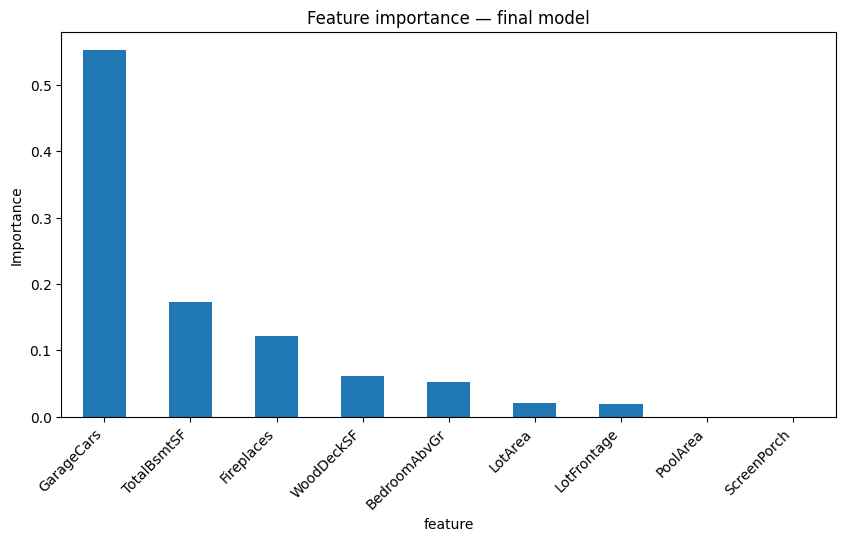

In [23]:
importance_df.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Feature importance — final model")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()


## 21. Visualization finalnego drzewa

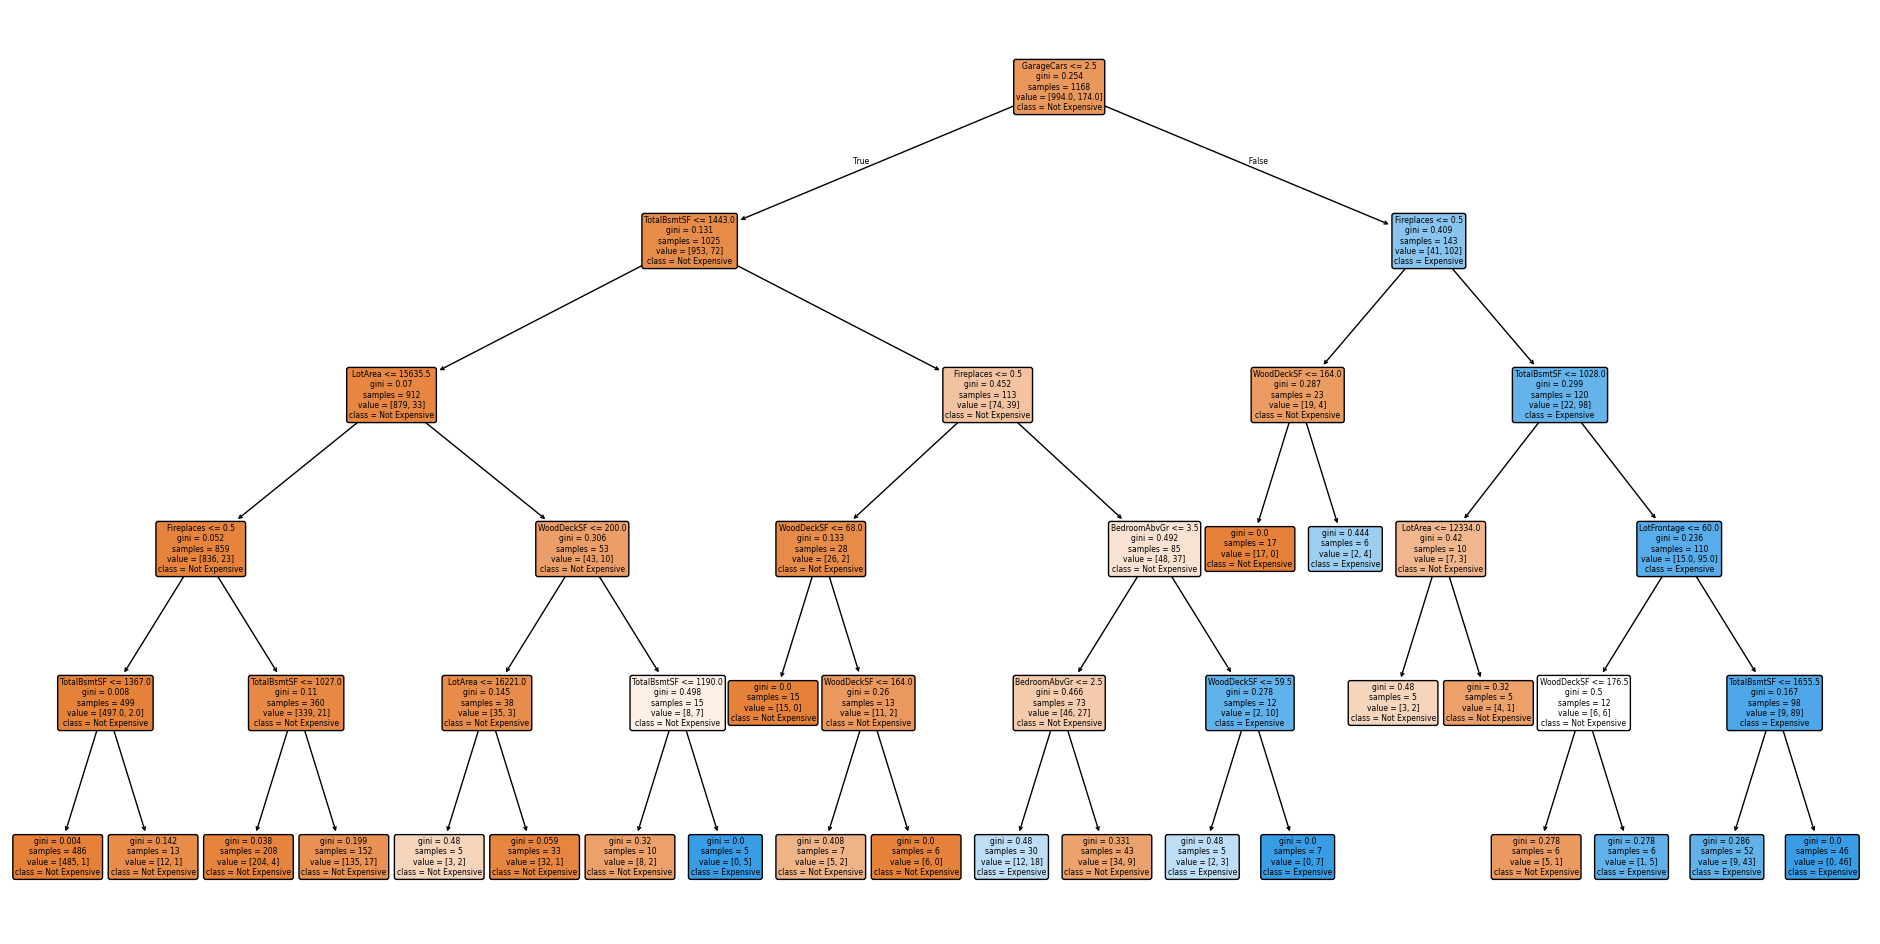

In [24]:
plt.figure(figsize=(24, 12))

plot_tree(
    final_tree,
    feature_names=features,
    class_names=["Not Expensive", "Expensive"],
    filled=True,
    rounded=True
)

plt.show()


## 22. Final conclusions

W tym notebooku ulepszyliśmy workflow względem prostego drzewa:

1. Baseline został potraktowany jako punkt odniesienia.
2. Missing values są obsłużone poprawnie w `Pipeline`.
3. Cross-validation daje stabilniejszą ocenę modelu.
4. Grid Search automatycznie dobiera hiperparametry.
5. Porównaliśmy dwa cele optymalizacji:
   - `f1`,
   - `recall`.
6. Dla niezbalansowanego datasetu nie wystarczy patrzeć na accuracy.
7. Model finalny powinien być wybrany zależnie od kosztu błędów.

Najważniejszy praktyczny wniosek:

> jeżeli bardziej boimy się przegapić drogie domy, wybieramy model optymalizowany pod recall;  
> jeżeli chcemy kompromis między precision i recall, wybieramy model optymalizowany pod f1.
